In [1]:
# This file simply reruns the best found programs to collect the AUC,ACC and F1 scores.

In [1]:
from keras.layers import Input, Dense
from keras.models import Model, Sequential
from keras import regularizers
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.manifold import TSNE
from sklearn import preprocessing 
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np
import seaborn as sns
import os
import tensorflow as tf

import sys
sys.path.append("../../") # Adds higher directory to python modules path.
from Modules.Tools import MapTool

In [2]:
from keras.models import Model, load_model
from keras.layers import Input,Dense, BatchNormalization #layers of autoencoder
from keras.callbacks import ModelCheckpoint, TensorBoard, EarlyStopping #callbacks
from keras import regularizers #regularization
import keras
import sklearn.metrics as metrics #metrics librry

In [3]:
import sys
# setting path
sys.path.append('../../')
from Modules.Tests import KNN_Exp

In [4]:
from tensorflow.python.client import device_lib
device_lib.list_local_devices()

[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 12861885465892207112
 xla_global_id: -1]

In [5]:
def printandwrite(loc, text, firstLine = False):       
    print(text)
    if firstLine:
        sourceFile = open(loc, 'w')
    else:
        sourceFile = open(loc, 'a')
    sourceFile.write(text)
    sourceFile.close()

# Load Datasets

## Synthetic

In [6]:
load_Folder = "../../Datasets/Numpy/Generated/"
alpha_Gen_Signals = np.load(load_Folder + "alpha_Gen_Signals.npy", allow_pickle = True)

## Real Normal

In [7]:
alpha_SNR_25 = np.load("../../Datasets/Numpy/WGN/alpha_SNR_25_MP.npy", allow_pickle=True)
alpha_SNR_20 = np.load("../../Datasets/Numpy/WGN/alpha_SNR_20_MP.npy", allow_pickle=True)
alpha_SNR_15 = np.load("../../Datasets/Numpy/WGN/alpha_SNR_15_MP.npy", allow_pickle=True)

## Real Anomalous

In [8]:
alpha_sub_SNR_25 = np.load("../../Datasets/Numpy/WGN/alpha_sub_SNR_25_MP.npy", allow_pickle=True)
alpha_sub_SNR_20 = np.load("../../Datasets/Numpy/WGN/alpha_sub_SNR_20_MP.npy", allow_pickle=True)
alpha_sub_SNR_15 = np.load("../../Datasets/Numpy/WGN/alpha_sub_SNR_15_MP.npy", allow_pickle=True)

# Graphs of Alpha and Alpha_Sub

In [9]:
alpha = np.load("../../Datasets/Numpy/FP_GANs_LargeScale_2/segment/Alpha/Alpha_segment.npy", allow_pickle=True)
alpha_sub = np.load("../../Datasets/Numpy/FP_GANs_LargeScale_2/segment/Alpha_sub/Alpha_sub_segment.npy", allow_pickle=True)

In [10]:
params = {'legend.fontsize': 50,
          'figure.figsize': (70, 15),
         'axes.labelsize': 60,
         'axes.titlesize':70,
         'xtick.labelsize':50,
         'ytick.labelsize':50,
          'font.weight': "bold",
         'lines.linewidth': 5}
plt.rcParams.update(params)

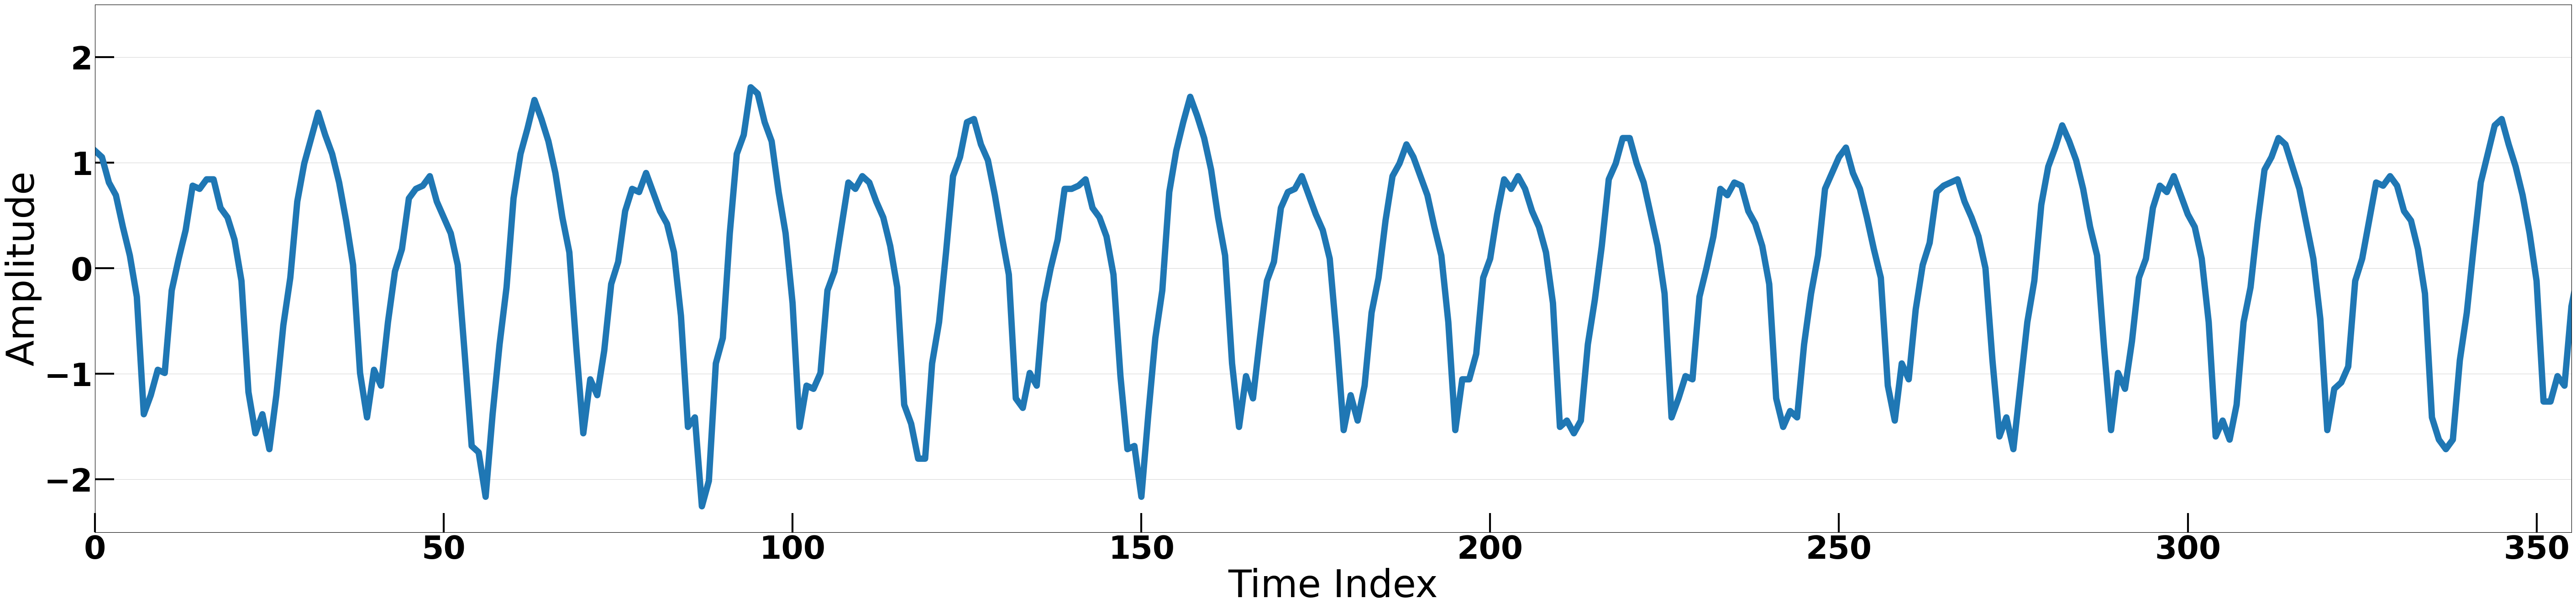

In [11]:
pad = 11

signal_original = alpha[0]
time_Signal = np.arange(signal_original.shape[0])
plt.plot(time_Signal, signal_original, label="", linewidth=10)
#plt.axvspan(MapTool.getPeaksLoc(signal_original, pad, 0), MapTool.getPeaksLoc(signal_original, pad, 10), color='red', alpha=0.5)
plt.xlabel("Time Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.xlim([0,355])
plt.ylim(-2.5,2.5)
#plt.xticks(np.arange(len(signal_original)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("Benign.png", bbox_inches='tight')     
plt.show()
plt.close()

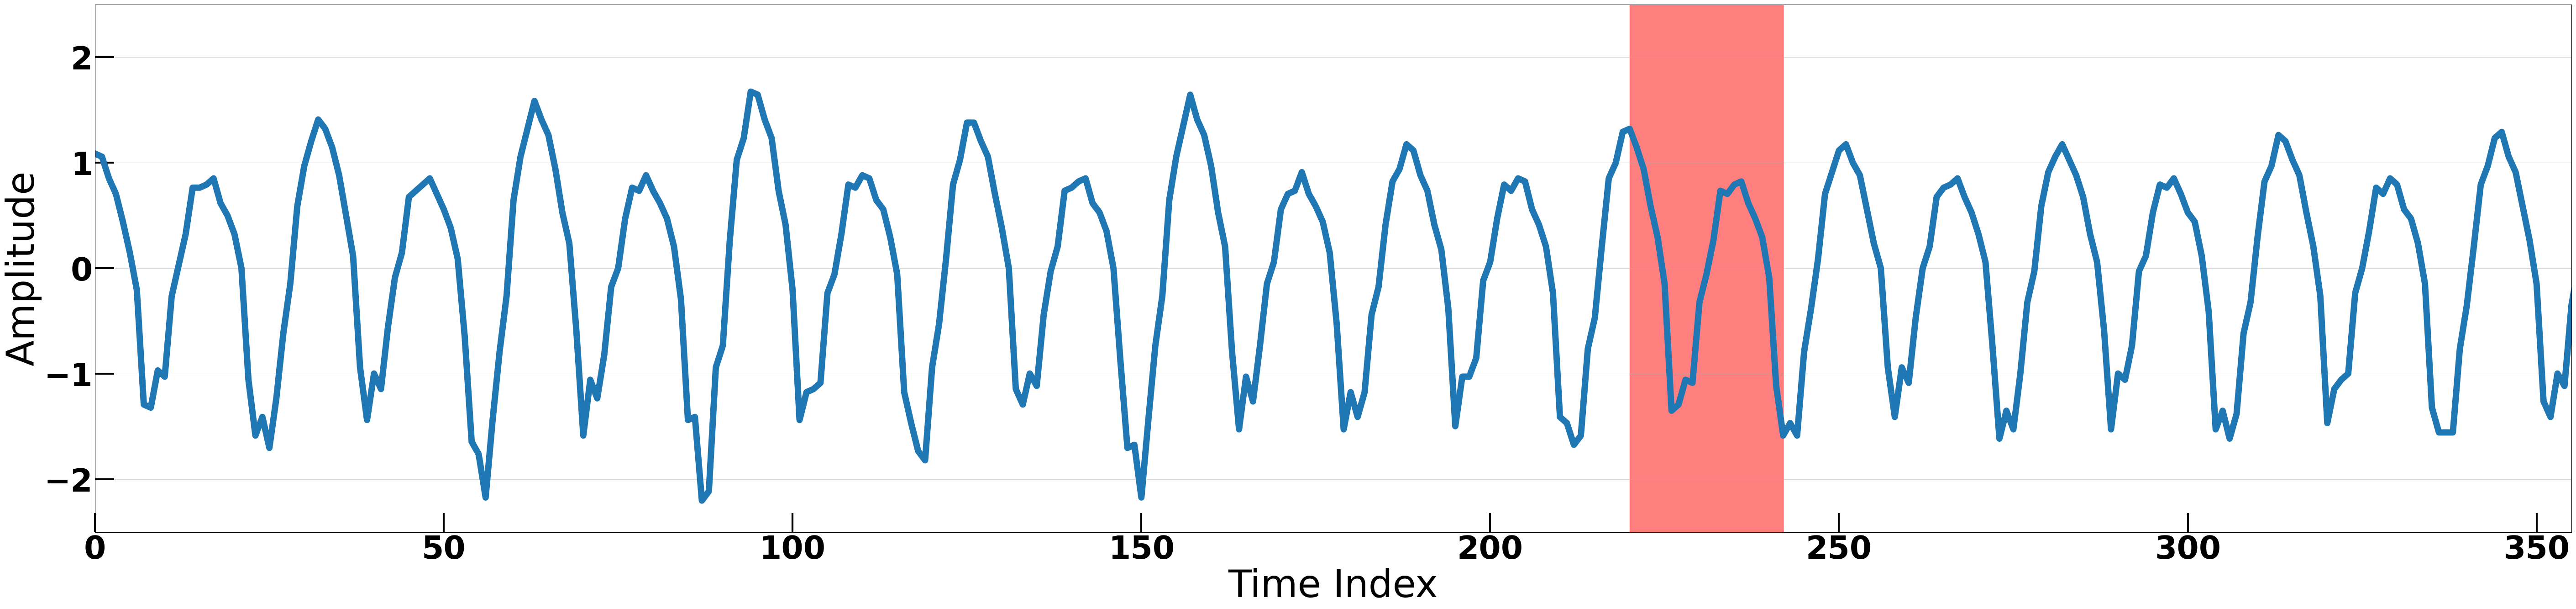

In [12]:
pad = 11

signal_original = alpha_sub[0]
time_Signal = np.arange(signal_original.shape[0])
plt.plot(time_Signal, signal_original, label="", linewidth=10)
plt.axvspan(MapTool.getPeaksLoc(signal_original, pad, 14), MapTool.getPeaksLoc(signal_original, pad, 15, False), color='red', alpha=0.5)
plt.xlabel("Time Index")
plt.ylabel("Amplitude")
plt.grid(axis='y')

plt.xlim([0,355])
plt.ylim(-2.5,2.5)
#plt.xticks(np.arange(len(signal_original)))
plt.tick_params(direction='in', length=30, width=3, grid_alpha=0.5)
plt.savefig("Anomalous.png", bbox_inches='tight')     
plt.show()
plt.close()

# Create Bar Chart of Results at 20 SNR

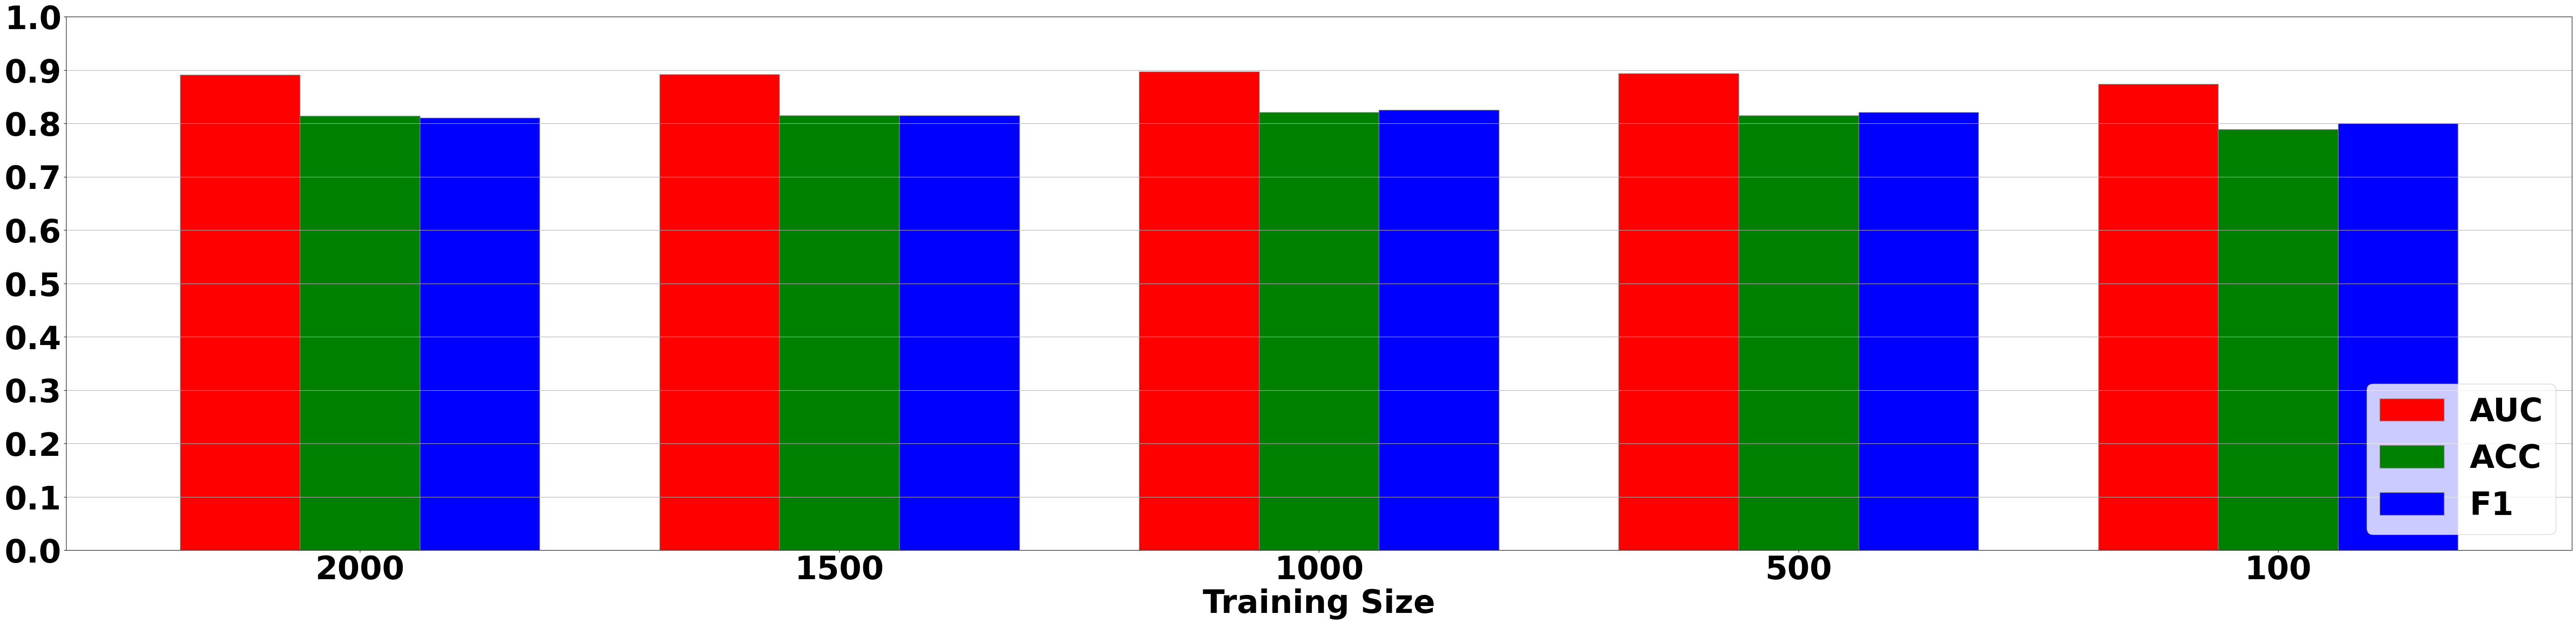

In [13]:
import numpy as np 
import matplotlib.pyplot as plt 
 
# set width of bar 
barWidth = 0.25
fig = plt.subplots(figsize =(70, 15)) 
 
# set height of bar 
AUC = [0.891, 0.892, 0.897, 0.894, 0.874] 
ACC = [0.814, 0.815, 0.821, 0.815, 0.789] 
F1 = [0.811, 0.815, 0.825, 0.821, 0.800] 
 
# Set position of bar on X axis 
br1 = np.arange(len(AUC)) 
br2 = [x + barWidth for x in br1] 
br3 = [x + barWidth for x in br2] 
 
# Make the plot
plt.bar(br1, AUC, color ='r', width = barWidth, 
        edgecolor ='grey', label ='AUC') 
plt.bar(br2, ACC, color ='g', width = barWidth, 
        edgecolor ='grey', label ='ACC') 
plt.bar(br3, F1, color ='b', width = barWidth, 
        edgecolor ='grey', label ='F1') 
 
# Adding Xticks 
plt.xlabel('Training Size', fontweight ='bold', fontsize = 50) 
plt.xticks([r + barWidth for r in range(len(AUC))], 
        ['2000', '1500', '1000', '500', '100'])
plt.yticks(np.arange(0,1.1,0.1))
plt.ylim([0,1])
plt.grid(axis='y')
plt.legend(loc=4)
plt.savefig("Bar_KNN_Real.png", bbox_inches='tight') 
plt.show() 

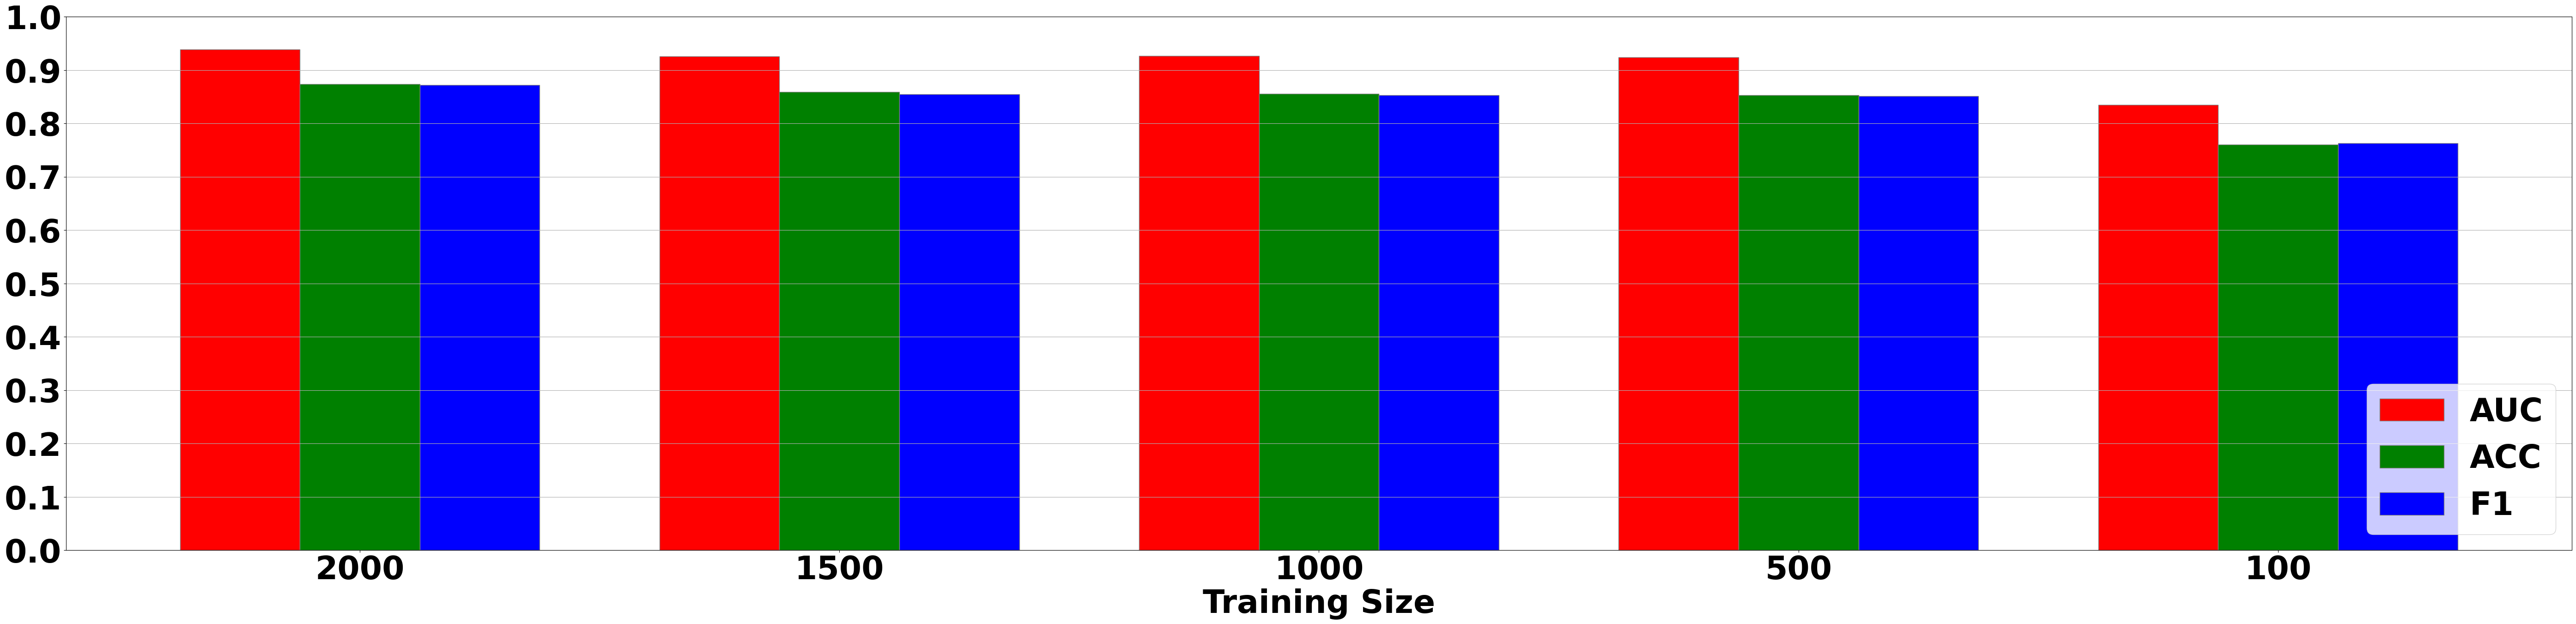

In [14]:
import numpy as np 
import matplotlib.pyplot as plt 
 
# set width of bar 
barWidth = 0.25
fig = plt.subplots(figsize =(70, 15)) 
 
# set height of bar 
AUC = [0.939, 0.926, 0.927, 0.924, 0.835] 
ACC = [0.874, 0.859, 0.856, 0.853, 0.760] 
F1 = [0.872, 0.855, 0.853, 0.851, 0.763] 
 
# Set position of bar on X axis 
br1 = np.arange(len(AUC)) 
br2 = [x + barWidth for x in br1] 
br3 = [x + barWidth for x in br2] 
 
# Make the plot
plt.bar(br1, AUC, color ='r', width = barWidth, 
        edgecolor ='grey', label ='AUC') 
plt.bar(br2, ACC, color ='g', width = barWidth, 
        edgecolor ='grey', label ='ACC') 
plt.bar(br3, F1, color ='b', width = barWidth, 
        edgecolor ='grey', label ='F1') 
 
# Adding Xticks 
plt.xlabel('Training Size', fontweight ='bold', fontsize = 50) 
plt.xticks([r + barWidth for r in range(len(AUC))], 
        ['2000', '1500', '1000', '500', '100'])
plt.yticks(np.arange(0,1.1,0.1))
plt.ylim([0,1])
plt.grid(axis='y')
plt.legend(loc=4)
plt.savefig("Bar_AE_Real.png", bbox_inches='tight') 
plt.show() 

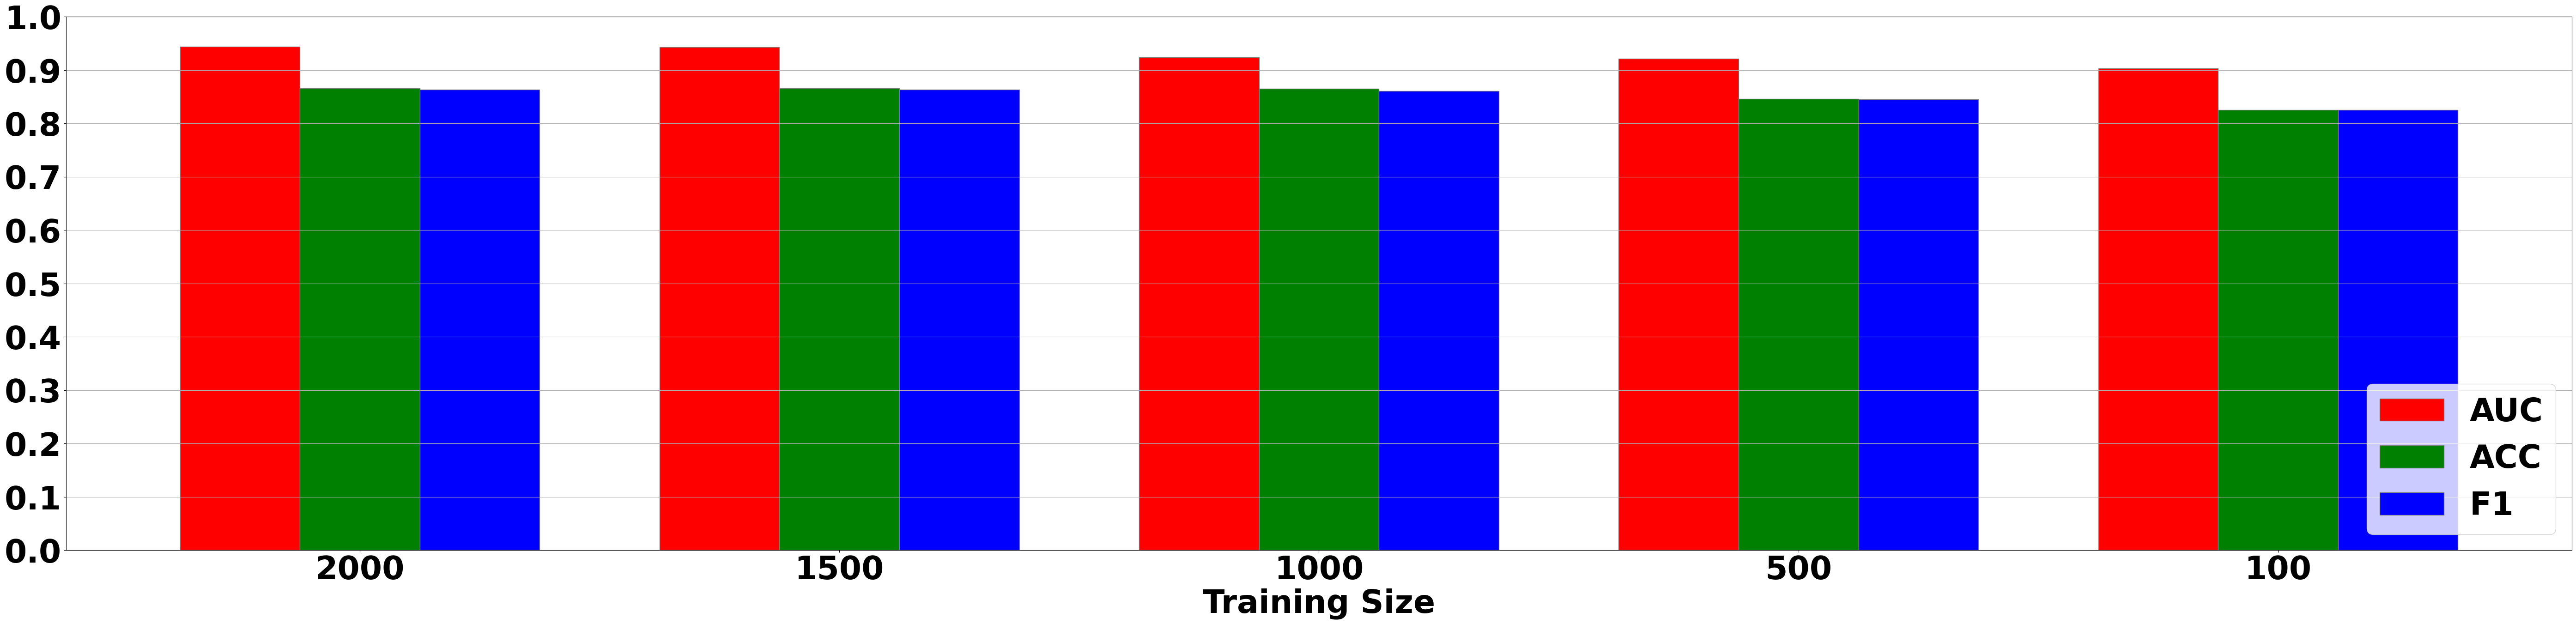

In [15]:
import numpy as np 
import matplotlib.pyplot as plt 
 
# set width of bar 
barWidth = 0.25
fig = plt.subplots(figsize =(70, 15)) 
 
# set height of bar 
AUC = [0.944, 0.943, 0.924, 0.921, 0.903] 
ACC = [0.866, 0.866, 0.865, 0.846, 0.825] 
F1 = [0.863, 0.863, 0.861, 0.845, 0.825] 
 
# Set position of bar on X axis 
br1 = np.arange(len(AUC)) 
br2 = [x + barWidth for x in br1] 
br3 = [x + barWidth for x in br2] 
 
# Make the plot
plt.bar(br1, AUC, color ='r', width = barWidth, 
        edgecolor ='grey', label ='AUC') 
plt.bar(br2, ACC, color ='g', width = barWidth, 
        edgecolor ='grey', label ='ACC') 
plt.bar(br3, F1, color ='b', width = barWidth, 
        edgecolor ='grey', label ='F1') 
 
# Adding Xticks 
plt.xlabel('Training Size', fontweight ='bold', fontsize = 50) 
plt.xticks([r + barWidth for r in range(len(AUC))], 
        ['2000', '1500', '1000', '500', '100'])
plt.yticks(np.arange(0,1.1,0.1))
plt.ylim([0,1])
plt.grid(axis='y')
plt.legend(loc=4)
plt.savefig("Bar_AE_Synth.png", bbox_inches='tight') 
plt.show() 

In [17]:
params = {'legend.fontsize': 50,
          'figure.figsize': (20, 15),
         'axes.labelsize': 60,
         'axes.titlesize':70,
         'xtick.labelsize':50,
         'ytick.labelsize':50,
          'font.weight': "bold",
         'lines.linewidth': 5}
plt.rcParams.update(params)

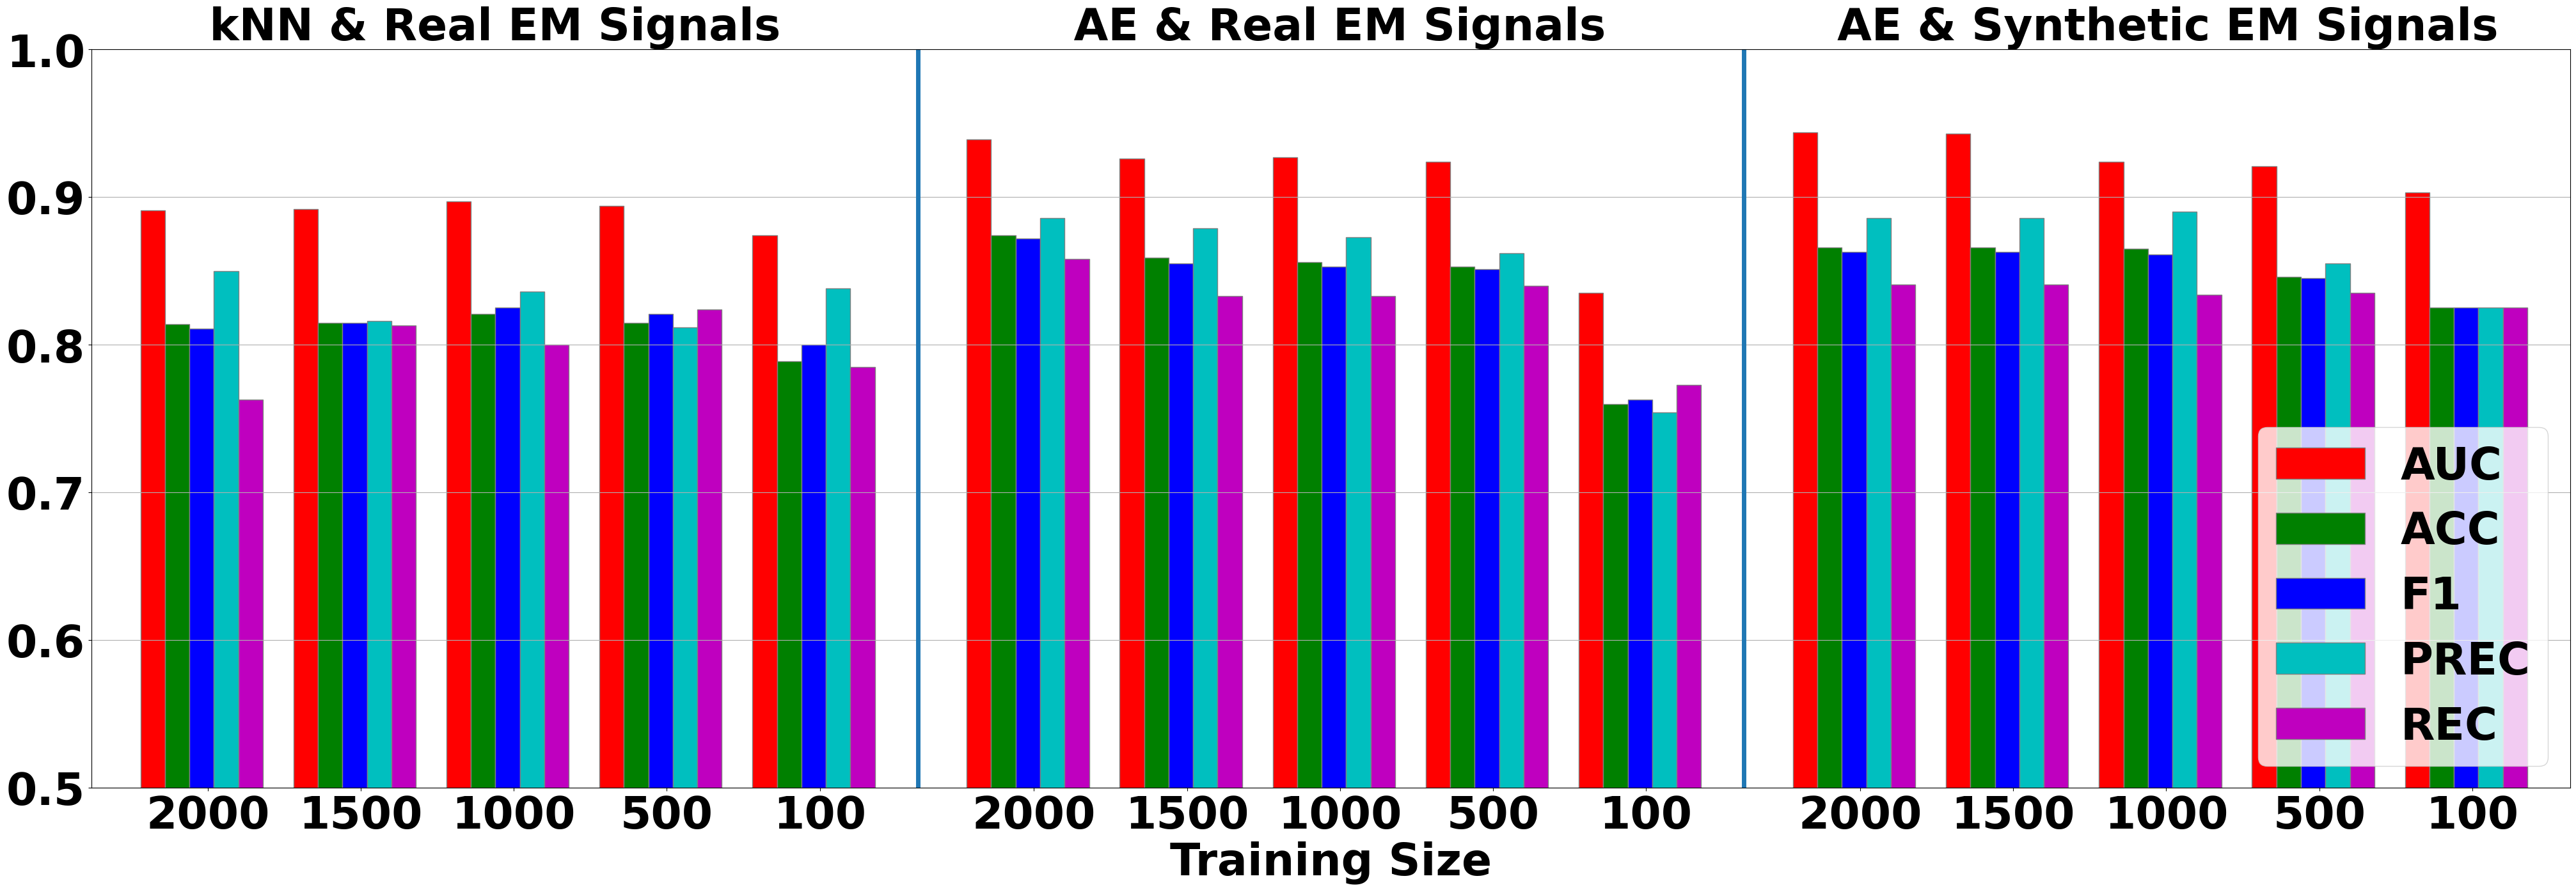

In [43]:
import numpy as np 
import matplotlib.pyplot as plt 
 
# set width of bar 
barWidth = 0.08
fig, ax = plt.subplots(figsize =(50, 15)) 
 
# set height of bar 
AUC = [0.891, 0.892, 0.897, 0.894, 0.874] 
ACC = [0.814, 0.815, 0.821, 0.815, 0.789] 
F1 = [0.811, 0.815, 0.825, 0.821, 0.800]
Prec = [0.850, 0.816, 0.836, 0.812, 0.838]
Rec = [0.763, 0.813, 0.800, 0.824, 0.785]
 
# Set position of bar on X axis 
br1 = [0.2, 0.7, 1.2, 1.7, 2.2]
br2 = [x + barWidth for x in br1] 
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
 
# Make the plot
plt.bar(br1, AUC, color ='r', width = barWidth, 
        edgecolor ='grey', label ='AUC') 
plt.bar(br2, ACC, color ='g', width = barWidth, 
        edgecolor ='grey', label ='ACC') 
plt.bar(br3, F1, color ='b', width = barWidth, 
        edgecolor ='grey', label ='F1')
plt.bar(br4, Prec, color ='c', width = barWidth, 
        edgecolor ='grey', label = 'PREC') 
plt.bar(br5, Rec, color ='m', width = barWidth, 
        edgecolor ='grey', label = "REC") 

# set height of bar 
AUC = [0.939, 0.926, 0.927, 0.924, 0.835] 
ACC = [0.874, 0.859, 0.856, 0.853, 0.760] 
F1 = [0.872, 0.855, 0.853, 0.851, 0.763]
Prec = [0.886, 0.879, 0.873, 0.862, 0.754]
Rec = [0.858, 0.833, 0.833, 0.840, 0.773]
 
# Set position of bar on X axis 
br1 = [2.9, 3.4, 3.9, 4.4, 4.9]
br2 = [x + barWidth for x in br1] 
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
 
# Make the plot
plt.bar(br1, AUC, color ='r', width = barWidth, 
        edgecolor ='grey') 
plt.bar(br2, ACC, color ='g', width = barWidth, 
        edgecolor ='grey') 
plt.bar(br3, F1, color ='b', width = barWidth, 
        edgecolor ='grey') 
plt.bar(br4, Prec, color ='c', width = barWidth, 
        edgecolor ='grey') 
plt.bar(br5, Rec, color ='m', width = barWidth, 
        edgecolor ='grey') 

# set height of bar 
AUC = [0.944, 0.943, 0.924, 0.921, 0.903] 
ACC = [0.866, 0.866, 0.865, 0.846, 0.825] 
F1 = [0.863, 0.863, 0.861, 0.845, 0.825]
Prec = [0.886, 0.886, 0.890, 0.855, 0.825]
Rec = [0.841, 0.841, 0.834, 0.835, 0.825]
 
# Set position of bar on X axis 
br1 = [5.6, 6.1, 6.6, 7.1, 7.6] 
br2 = [x + barWidth for x in br1] 
br3 = [x + barWidth for x in br2] 
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
 
# Make the plot
plt.bar(br1, AUC, color ='r', width = barWidth, 
        edgecolor ='grey') 
plt.bar(br2, ACC, color ='g', width = barWidth, 
        edgecolor ='grey') 
plt.bar(br3, F1, color ='b', width = barWidth, 
        edgecolor ='grey')
plt.bar(br4, Prec, color ='c', width = barWidth, 
        edgecolor ='grey') 
plt.bar(br5, Rec, color ='m', width = barWidth, 
        edgecolor ='grey') 

 
# Adding Xticks 
plt.xlabel('Training Size', fontweight ='bold', fontsize = 50) 
#plt.xticks([r + barWidth for r in [0.3, 0.9, 1.5, 1.499, 1.501, 2.1, 2.7, 3.5, 4.1, 4.7, 4.699, 4.701, 5.3, 5.9, 6.7, 7.3, 7.9, 7.899, 7.901, 8.5, 9.1]], 
#        ['2000', '1500', '1000', '\n\nkNN & Real EM Signals', '\nTraining Size', '500', '100', 
#         '2000', '1500', '1000', '\n\nAE & Real EM Signals', '\nTraining Size', '500', '100',
#        '2000', '1500', '1000', '\n\nAE & Synthetic EM Signals', '\nTraining Size', '500', '100'])

plt.xticks([r + barWidth for r in [0.3, 0.8, 1.3, 1.8, 2.3, 3.0, 3.5, 4.0, 4.5, 5.0, 5.7, 6.2, 6.7, 7.2, 7.7]], 
        ['2000', '1500', '1000', '500', '100', 
         '2000', '1500', '1000', '500', '100',
        '2000', '1500', '1000', '500', '100'])


plt.yticks(np.arange(0,1.1,0.1))
plt.ylim([0.5,1])
plt.xlim([0,8.1])
plt.axvline(x=2.7)
plt.axvline(x=5.4)
plt.grid(axis='y')
plt.legend(loc=4)
plt.title('   kNN & Real EM Signals                   AE & Real EM Signals               AE & Synthetic EM Signals', weight="bold", fontsize=50)
plt.savefig("Bar_AD_SNR20-With_Prec&Recall.png", bbox_inches='tight') 
plt.show() 

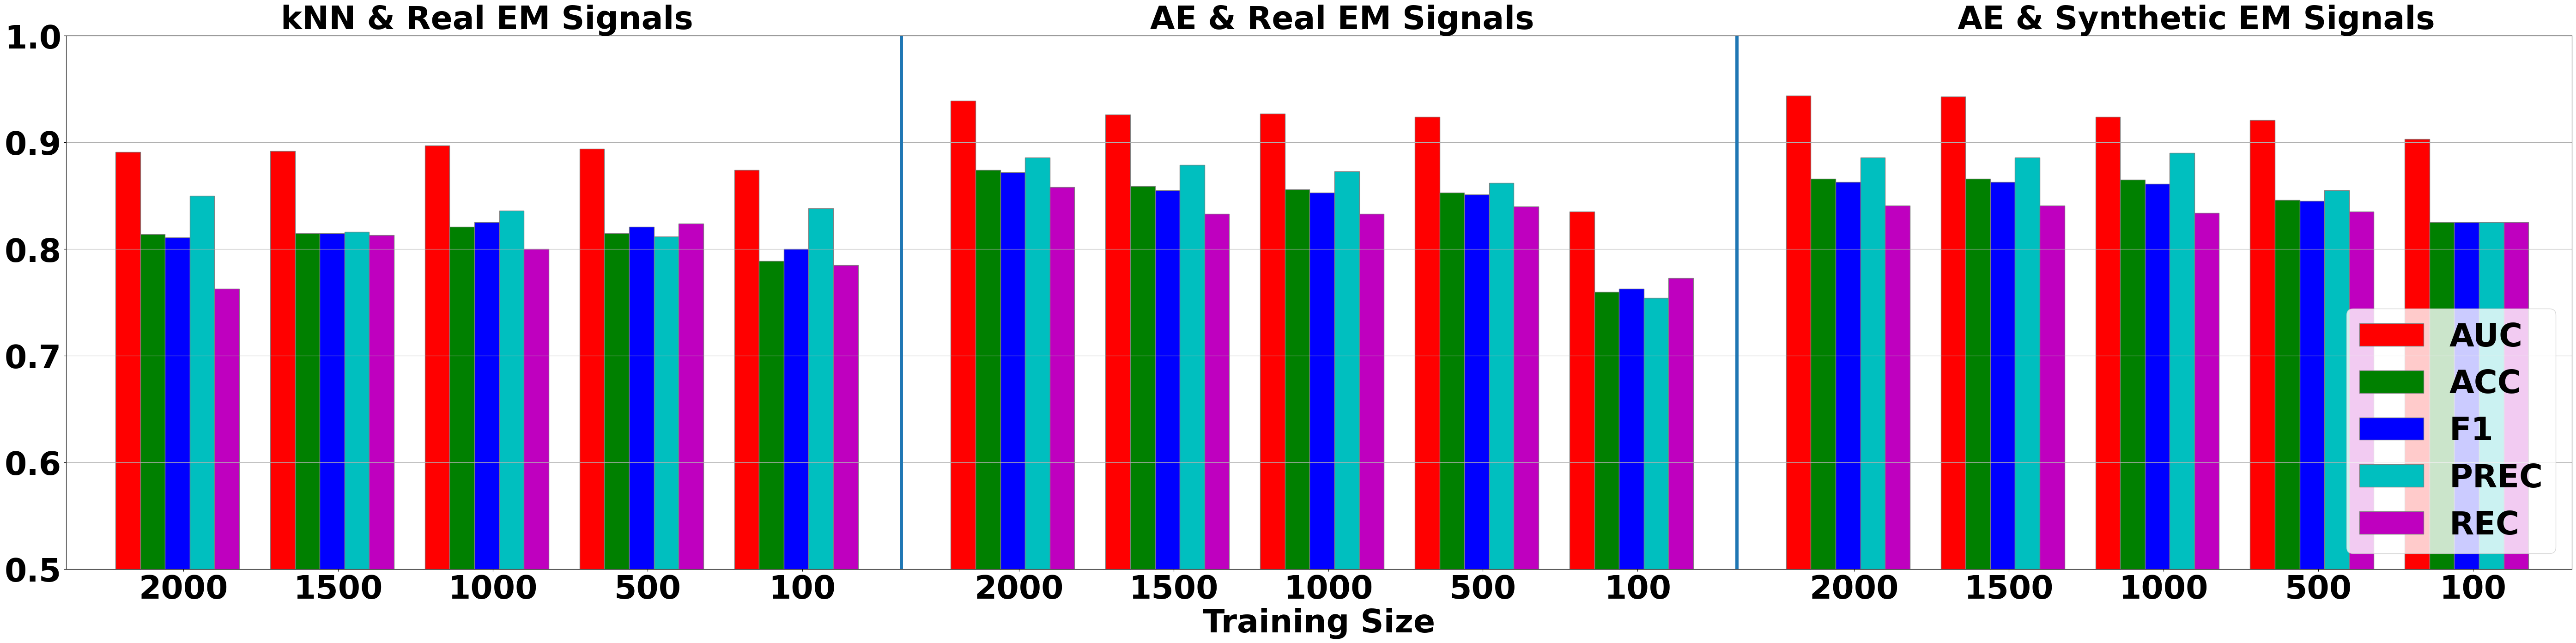

In [59]:
import numpy as np 
import matplotlib.pyplot as plt 
 
# set width of bar 
barWidth = 0.08
fig, ax = plt.subplots(figsize =(70, 15)) 
 
# set height of bar 
AUC = [0.891, 0.892, 0.897, 0.894, 0.874] 
ACC = [0.814, 0.815, 0.821, 0.815, 0.789] 
F1 = [0.811, 0.815, 0.825, 0.821, 0.800]
Prec = [0.850, 0.816, 0.836, 0.812, 0.838]
Rec = [0.763, 0.813, 0.800, 0.824, 0.785]
 
# Set position of bar on X axis 
br1 = [0.2, 0.7, 1.2, 1.7, 2.2]
br2 = [x + barWidth for x in br1] 
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
 
# Make the plot
plt.bar(br1, AUC, color ='r', width = barWidth, 
        edgecolor ='grey', label ='AUC') 
plt.bar(br2, ACC, color ='g', width = barWidth, 
        edgecolor ='grey', label ='ACC') 
plt.bar(br3, F1, color ='b', width = barWidth, 
        edgecolor ='grey', label ='F1')
plt.bar(br4, Prec, color ='c', width = barWidth, 
        edgecolor ='grey', label = 'PREC') 
plt.bar(br5, Rec, color ='m', width = barWidth, 
        edgecolor ='grey', label = "REC") 

# set height of bar 
AUC = [0.939, 0.926, 0.927, 0.924, 0.835] 
ACC = [0.874, 0.859, 0.856, 0.853, 0.760] 
F1 = [0.872, 0.855, 0.853, 0.851, 0.763]
Prec = [0.886, 0.879, 0.873, 0.862, 0.754]
Rec = [0.858, 0.833, 0.833, 0.840, 0.773]
 
# Set position of bar on X axis 
br1 = [2.9, 3.4, 3.9, 4.4, 4.9]
br2 = [x + barWidth for x in br1] 
br3 = [x + barWidth for x in br2]
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
 
# Make the plot
plt.bar(br1, AUC, color ='r', width = barWidth, 
        edgecolor ='grey') 
plt.bar(br2, ACC, color ='g', width = barWidth, 
        edgecolor ='grey') 
plt.bar(br3, F1, color ='b', width = barWidth, 
        edgecolor ='grey') 
plt.bar(br4, Prec, color ='c', width = barWidth, 
        edgecolor ='grey') 
plt.bar(br5, Rec, color ='m', width = barWidth, 
        edgecolor ='grey') 

# set height of bar 
AUC = [0.944, 0.943, 0.924, 0.921, 0.903] 
ACC = [0.866, 0.866, 0.865, 0.846, 0.825] 
F1 = [0.863, 0.863, 0.861, 0.845, 0.825]
Prec = [0.886, 0.886, 0.890, 0.855, 0.825]
Rec = [0.841, 0.841, 0.834, 0.835, 0.825]
 
# Set position of bar on X axis 
br1 = [5.6, 6.1, 6.6, 7.1, 7.6] 
br2 = [x + barWidth for x in br1] 
br3 = [x + barWidth for x in br2] 
br4 = [x + barWidth for x in br3]
br5 = [x + barWidth for x in br4]
 
# Make the plot
plt.bar(br1, AUC, color ='r', width = barWidth, 
        edgecolor ='grey') 
plt.bar(br2, ACC, color ='g', width = barWidth, 
        edgecolor ='grey') 
plt.bar(br3, F1, color ='b', width = barWidth, 
        edgecolor ='grey')
plt.bar(br4, Prec, color ='c', width = barWidth, 
        edgecolor ='grey') 
plt.bar(br5, Rec, color ='m', width = barWidth, 
        edgecolor ='grey') 

 
# Adding Xticks 
plt.xlabel('Training Size', fontweight ='bold', fontsize = 50) 
#plt.xticks([r + barWidth for r in [0.3, 0.9, 1.5, 1.499, 1.501, 2.1, 2.7, 3.5, 4.1, 4.7, 4.699, 4.701, 5.3, 5.9, 6.7, 7.3, 7.9, 7.899, 7.901, 8.5, 9.1]], 
#        ['2000', '1500', '1000', '\n\nkNN & Real EM Signals', '\nTraining Size', '500', '100', 
#         '2000', '1500', '1000', '\n\nAE & Real EM Signals', '\nTraining Size', '500', '100',
#        '2000', '1500', '1000', '\n\nAE & Synthetic EM Signals', '\nTraining Size', '500', '100'])

plt.xticks([r + barWidth for r in [0.3, 0.8, 1.3, 1.8, 2.3, 3.0, 3.5, 4.0, 4.5, 5.0, 5.7, 6.2, 6.7, 7.2, 7.7]], 
        ['2000', '1500', '1000', '500', '100', 
         '2000', '1500', '1000', '500', '100',
        '2000', '1500', '1000', '500', '100'])


plt.yticks(np.arange(0,1.1,0.1))
plt.ylim([0.5,1])
plt.xlim([0,8.1])
plt.axvline(x=2.7)
plt.axvline(x=5.4)
plt.grid(axis='y')
plt.legend(loc=4)
plt.title('       kNN & Real EM Signals                                         AE & Real EM Signals                                      AE & Synthetic EM Signals', weight="bold", fontsize=50)
plt.savefig("Bar_AD_SNR20-With_Prec&Recall.png", bbox_inches='tight') 
plt.show() 

# To compare the similarity using euclidean distance, we need the signal data to be the same lenght. As such, we will remove access information at the end as we assume we have knowledge of the length of time the benign program will take.

In [16]:
def cutToLength(dataset, length):
    new_Dataset = np.zeros((dataset.shape[0],length))
    
    for i in range(dataset.shape[0]):
        temp = dataset[i]
        new_Dataset[i] = temp[:length]
    
    new_Dataset = np.array(new_Dataset)
    return new_Dataset

# alpha

In [17]:
print(alpha_SNR_30.shape)

(3000, 12)


In [18]:
print(alpha_sub_SNR_25.shape)
print(alpha_sub_SNR_20.shape)
print(alpha_sub_SNR_15.shape)

(1312, 13)
(1312, 13)
(1312, 13)
(1312, 13)
(1312, 13)


In [19]:
alpha_sub_SNR_25 = cutToLength(alpha_sub_SNR_25, 12)
alpha_sub_SNR_20 = cutToLength(alpha_sub_SNR_20, 12)
alpha_sub_SNR_15 = cutToLength(alpha_sub_SNR_15, 12)
print(alpha_SNR_20.shape)
print(alpha_sub_SNR_20.shape)

(3000, 12)
(1312, 12)


# Data Collection Methods

In [20]:
## Method for autoencoder, real noisy training

In [21]:
def autoencoder_Real(program_N, program_A, program, SNR, train_amount, show=False):   
    save_path = "./Results/AE/" + program + "_SNR_" + str(SNR) + "/" + str(train_amount) + "/"

    if show:
        # Show results of best model
        import matplotlib.pyplot as plt

        params = {'legend.fontsize': 50,
                  'figure.figsize': (45, 15),
                 'axes.labelsize': 60,
                 'axes.titlesize':70,
                 'xtick.labelsize':50,
                 'ytick.labelsize':50,
                  'font.weight': "bold",
                 'lines.linewidth': 5}
        plt.rcParams.update(params)
    
    # Dataset
    train_N = np.copy(program_N[0:train_amount])
    test_N = np.copy(program_N[2000:3000])
    test_A = np.copy(program_A[0:1000])
    # Create the X_train, X_test, and y_test
    X_train = train_N.astype('float32')
    X_test = np.concatenate((test_N, test_A)).astype('float32')

    zeros = np.repeat(0,test_N.shape[0])
    ones = np.repeat(1,test_A.shape[0])
    y_test = np.concatenate((zeros,ones))

    # Semi-supervised AutoEncoder
    from numpy.random import seed
    seed(4)
    input_dim = X_train.shape[1]

    Input_layer=Input(shape=(input_dim,))


    ## Create model
    Input_layer=Input(shape=(input_dim,))
    #encoder
    encoding_dim = 100
    from keras import initializers
    #init = initializers.VarianceScaling(scale=1.0, mode='fan_in', distribution='normal', seed=42)
    #encoder
    encoder=Dense(units=100,activation='tanh', use_bias=False, 
                  activity_regularizer=regularizers.l1(10e-5))(Input_layer)
    encoder=BatchNormalization()(encoder)
    encoder=Dense(units=int(50), activation='relu')(encoder)
    encoder=Dense(units=int(25), activation='relu')(encoder)

    #decoder
    decoder=Dense(units=int(50), activation='relu')(encoder)
    decoder=Dense(units=int(100), activation='relu')(decoder)
    decoder=Dense(units=input_dim,activation='relu')(decoder)

    #model
    autoencoder=Model(inputs=Input_layer,outputs=decoder)
    encodermodel=Model(inputs=Input_layer,outputs=encoder)

    # Load best weights (no training as its already done)
    autoencoder.load_weights(save_path + "best_weigths.hdf5")

    # Predict
    predictions_AE=autoencoder.predict(X_test, verbose=0)

    # Find the mean square error
    mse=np.mean(np.power(X_test - predictions_AE, 2), axis=1)

    fpr, tpr, tresholds = metrics.roc_curve(y_test, mse)
    scores_AE=[]
    for treshold in tresholds:
        y_hat_AE = (mse > treshold).astype(int)
        scores_AE.append([metrics.accuracy_score(y_pred=y_hat_AE, y_true=y_test),
                          metrics.f1_score(y_pred=y_hat_AE, y_true=y_test),
                         metrics.recall_score(y_pred=y_hat_AE, y_true=y_test),
                         metrics.precision_score(y_pred=y_hat_AE, y_true=y_test, zero_division=0.0),
                         metrics.fbeta_score(y_pred=y_hat_AE, y_true=y_test, beta=2),
                         metrics.cohen_kappa_score(y1=y_hat_AE, y2=y_test)])

    roc_auc = metrics.auc(fpr, tpr)
    
    if show:
        # method I: plt
        import matplotlib.pyplot as plt
        plt.title('Receiver Operating Characteristic')
        plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
        plt.legend(loc = 'lower right')
        plt.plot([0, 1], [0, 1],'r--')
        plt.xlim([0, 1])
        plt.ylim([0, 1])
        plt.ylabel('True Positive Rate')
        plt.xlabel('False Positive Rate')
        plt.savefig(save_path + "ROC_" + program + "_TrainSize_" + str(train_amount) + ".png", bbox_inches='tight')
        plt.show()

    scores_AE = np.array(scores_AE)
    final_tresh = tresholds[scores_AE[:, 0].argmax()]
    y_hat_AE = (mse > final_tresh).astype(int)
    best_score_AE = scores_AE[scores_AE[:, 0].argmax(),:]
    accuracy_score_AE = best_score_AE[0]
    f1_score_AE = best_score_AE[1]
    recall_score_AE = best_score_AE[2]
    precision_score_AE = best_score_AE[3]
    fbeta_score_AE = best_score_AE[4]
    cohen_kappa_score_AE = best_score_AE[5]
    
    if show:
        params = {'legend.fontsize': 30,
                  'figure.figsize': (15, 15),
                 'axes.labelsize': 40,
                 'axes.titlesize':30,
                 'xtick.labelsize':30,
                 'ytick.labelsize':30,
                  'font.weight': "bold",
                 'lines.linewidth': 5}
        plt.rcParams.update(params)



        print('The accuracy score is": %.3f' % accuracy_score_AE)
        print('The f1 score is": %.3f' % f1_score_AE)
        print('The recall score is": %.3f' % recall_score_AE)
        print('The precision score is": %.3f' % precision_score_AE)
        print('The f2 score is": %.3f' % fbeta_score_AE)
        print('The Kappa score is": %.3f' % cohen_kappa_score_AE)
        target_names = ['class 0 (Normal)', 'class 1 (Fraud)']
        print(classification_report(y_test, y_hat_AE, target_names=target_names))

        cm = pd.crosstab(y_test, y_hat_AE, rownames=['Actual'], colnames=['Predicted'])
        fig, (ax1) = plt.subplots(ncols=1, figsize=(15,15))
        sns.heatmap(cm, 
                    xticklabels=['Benign', 'Anomalous'],
                    yticklabels=['Benign', 'Anomalous'],
                    annot=True,ax=ax1,
                    linewidths=.2,linecolor="Darkblue", cmap="Blues", fmt='d', annot_kws={"fontsize":25})
        plt.title('', fontsize=100)
        plt.savefig(save_path + "CM_" + program + "_TrainSize_" + str(train_amount) + ".png", bbox_inches='tight')
        plt.show()

    del autoencoder
    keras.backend.clear_session()
    
    return tpr, fpr, roc_auc

In [22]:
## Method for autoencoder, synthetic training

In [23]:
def autoencoder_Synth(program_N_Train, program_N_Test, program_A, program, SNR, train_amount, show=False):   
    program = program + "_T-Synth"
    
    save_path = "./Results/AE/" + program + "_SNR_" + str(SNR) + "/" + str(train_amount) + "/"
    
    if show:
        # Show results of best model
        import matplotlib.pyplot as plt

        params = {'legend.fontsize': 50,
                  'figure.figsize': (45, 15),
                 'axes.labelsize': 60,
                 'axes.titlesize':70,
                 'xtick.labelsize':50,
                 'ytick.labelsize':50,
                  'font.weight': "bold",
                 'lines.linewidth': 5}
        plt.rcParams.update(params)

    # Dataset
    train_N = np.copy(program_N_Train[0:train_amount])
    test_N = np.copy(program_N_Test[2000:3000])
    test_A = np.copy(program_A[0:1000])
    # Create the X_train, X_test, and y_test
    X_train = train_N.astype('float32')
    X_test = np.concatenate((test_N, test_A)).astype('float32')

    zeros = np.repeat(0,test_N.shape[0])
    ones = np.repeat(1,test_A.shape[0])
    y_test = np.concatenate((zeros,ones))

    # Semi-supervised AutoEncoder
    from numpy.random import seed
    seed(4)
    input_dim = X_train.shape[1]

    Input_layer=Input(shape=(input_dim,))


    ## Create model
    Input_layer=Input(shape=(input_dim,))
    #encoder
    encoding_dim = 100
    from keras import initializers
    #init = initializers.VarianceScaling(scale=1.0, mode='fan_in', distribution='normal', seed=42)
    #encoder
    encoder=Dense(units=100,activation='tanh', use_bias=False, 
                  activity_regularizer=regularizers.l1(10e-5))(Input_layer)
    encoder=BatchNormalization()(encoder)
    encoder=Dense(units=int(50), activation='relu')(encoder)
    encoder=Dense(units=int(25), activation='relu')(encoder)

    #decoder
    decoder=Dense(units=int(50), activation='relu')(encoder)
    decoder=Dense(units=int(100), activation='relu')(decoder)
    decoder=Dense(units=input_dim,activation='relu')(decoder)

    #model
    autoencoder=Model(inputs=Input_layer,outputs=decoder)
    encodermodel=Model(inputs=Input_layer,outputs=encoder)

    # Load best weights (no training as its already done)
    autoencoder.load_weights(save_path + "best_weigths.hdf5")

    # Predict
    predictions_AE=autoencoder.predict(X_test, verbose=0)

    # Find the mean square error
    mse=np.mean(np.power(X_test - predictions_AE, 2), axis=1)

    fpr, tpr, tresholds = metrics.roc_curve(y_test, mse)
    scores_AE=[]
    for treshold in tresholds:
        y_hat_AE = (mse > treshold).astype(int)
        scores_AE.append([metrics.accuracy_score(y_pred=y_hat_AE, y_true=y_test),
                          metrics.f1_score(y_pred=y_hat_AE, y_true=y_test),
                         metrics.recall_score(y_pred=y_hat_AE, y_true=y_test),
                         metrics.precision_score(y_pred=y_hat_AE, y_true=y_test, zero_division=0.0),
                         metrics.fbeta_score(y_pred=y_hat_AE, y_true=y_test, beta=2),
                         metrics.cohen_kappa_score(y1=y_hat_AE, y2=y_test)])

    roc_auc = metrics.auc(fpr, tpr)
    
    if show:
        # method I: plt
        import matplotlib.pyplot as plt
        plt.title('Receiver Operating Characteristic')
        plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
        plt.legend(loc = 'lower right')
        plt.plot([0, 1], [0, 1],'r--')
        plt.xlim([0, 1])
        plt.ylim([0, 1])
        plt.ylabel('True Positive Rate')
        plt.xlabel('False Positive Rate')
        plt.savefig(save_path + "ROC_" + program + "_TrainSize_" + str(train_amount) + ".png", bbox_inches='tight')
        plt.show()

    scores_AE = np.array(scores_AE)
    final_tresh = tresholds[scores_AE[:, 0].argmax()]
    y_hat_AE = (mse > final_tresh).astype(int)
    best_score_AE = scores_AE[scores_AE[:, 0].argmax(),:]
    accuracy_score_AE = best_score_AE[0]
    f1_score_AE = best_score_AE[1]
    recall_score_AE = best_score_AE[2]
    precision_score_AE = best_score_AE[3]
    fbeta_score_AE = best_score_AE[4]
    cohen_kappa_score_AE = best_score_AE[5]
    
    if show:
        params = {'legend.fontsize': 30,
                  'figure.figsize': (15, 15),
                 'axes.labelsize': 40,
                 'axes.titlesize':30,
                 'xtick.labelsize':30,
                 'ytick.labelsize':30,
                  'font.weight': "bold",
                 'lines.linewidth': 5}
        plt.rcParams.update(params)



        print('The accuracy score is": %.3f' % accuracy_score_AE)
        print('The f1 score is": %.3f' % f1_score_AE)
        print('The recall score is": %.3f' % recall_score_AE)
        print('The precision score is": %.3f' % precision_score_AE)
        print('The f2 score is": %.3f' % fbeta_score_AE)
        print('The Kappa score is": %.3f' % cohen_kappa_score_AE)
        target_names = ['class 0 (Normal)', 'class 1 (Fraud)']
        print(classification_report(y_test, y_hat_AE, target_names=target_names))

        cm = pd.crosstab(y_test, y_hat_AE, rownames=['Actual'], colnames=['Predicted'])
        fig, (ax1) = plt.subplots(ncols=1, figsize=(15,15))
        sns.heatmap(cm, 
                    xticklabels=['Benign', 'Anomalous'],
                    yticklabels=['Benign', 'Anomalous'],
                    annot=True,ax=ax1,
                    linewidths=.2,linecolor="Darkblue", cmap="Blues", fmt='d', annot_kws={"fontsize":25})
        plt.title('', fontsize=100)
        plt.savefig(save_path + "CM_" + program + "_TrainSize_" + str(train_amount) + ".png", bbox_inches='tight')
        plt.show()

    del autoencoder
    keras.backend.clear_session()
    
    return tpr, fpr, roc_auc

In [24]:
## Method for kNN

In [25]:
def kNN_Real(program_N, program_A, program, SNR, train_amount, show=False):
    folder = "./Results/kNN/" + program + "_SNR_" + SNR + "/"
    
    Training_Amount = train_amount

    NormalTrain = program_N[0:Training_Amount]
    NormalTest = program_N[2000:3000]
    AnomalyTest = program_A[0:1000]

    normalTrainInst = "alpha SNR-" + SNR + " TS-" + str(Training_Amount)
    normalTestInst = "alpha SNR-" +SNR
    anomalyInst = "alpha_sub SNR-" +SNR

    name = normalTrainInst + " vs " + anomalyInst

    path = folder + name + "/"

    kFold = 1

    neighbor = np.array([10])
    
    # Show results of best model
    import matplotlib.pyplot as plt

    if show:
        params = {'legend.fontsize': 50,
                  'figure.figsize': (45, 15),
                 'axes.labelsize': 60,
                 'axes.titlesize':70,
                 'xtick.labelsize':50,
                 'ytick.labelsize':50,
                  'font.weight': "bold",
                 'lines.linewidth': 5}
        plt.rcParams.update(params)

    tpr, fpr, roc_auc = KNN_Exp.runExperiment_once_AUC(NormalTrain, NormalTest, AnomalyTest, normalTrainInst, 
                                                        normalTestInst, anomalyInst, name, path, neighbors = neighbor, numFold = kFold,
                                                    show_Info=show)
    return tpr, fpr, roc_auc

# individual - Below is to reload the results of the fpr and tpr files to retreive the results in more detail. 
- I.E. instead of AUC given in 2 decimal points, get for 3 or 4 decimal point approximation.

# Combo AUC Graphs

In [38]:
params = {'legend.fontsize': 50,
                  'figure.figsize': (45, 15),
                 'axes.labelsize': 60,
                 'axes.titlesize':70,
                 'xtick.labelsize':50,
                 'ytick.labelsize':50,
                  'font.weight': "bold",
                 'lines.linewidth': 10}
plt.rcParams.update(params)

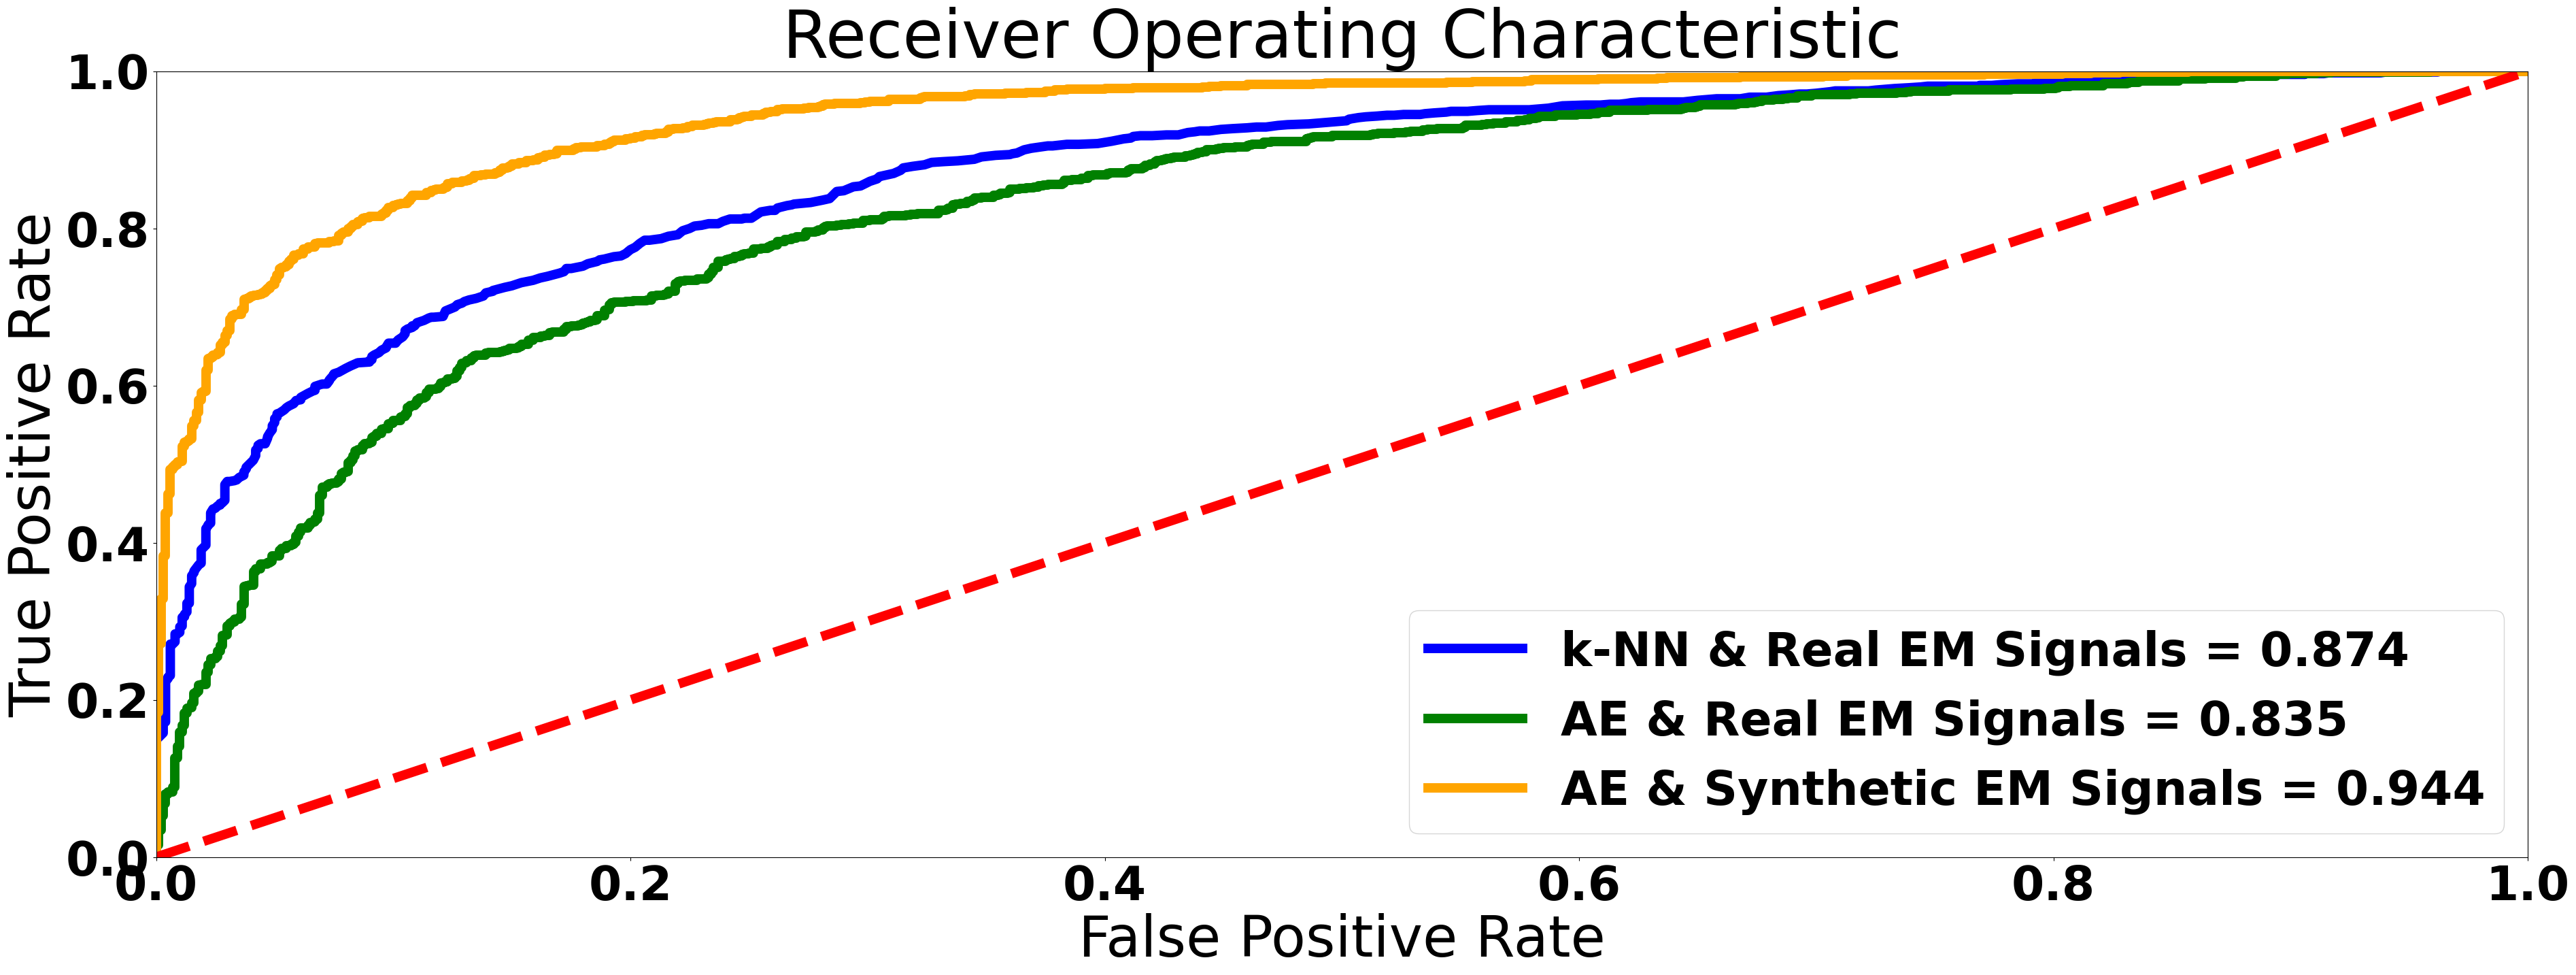

In [39]:
auc_KNN_R = metrics.auc(fpr_KNN_R, tpr_KNN_R)
auc_AE_R = metrics.auc(fpr_AE_R, tpr_AE_R)
auc_AE_S = metrics.auc(fpr_AE_S, tpr_AE_S)

    
plt.title('Receiver Operating Characteristic')
plt.plot(fpr_KNN_R, tpr_KNN_R, 'b', label = 'k-NN & Real EM Signals = %0.3f' % auc_KNN_R)
plt.plot(fpr_AE_R, tpr_AE_R, 'g', label = 'AE & Real EM Signals = %0.3f' % auc_AE_R)
plt.plot(fpr_AE_S, tpr_AE_S, 'orange', label = 'AE & Synthetic EM Signals = %0.3f' % auc_AE_S)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.savefig("./Results/" + "ROC_Real_VS_Synth.png", bbox_inches='tight')
plt.show()

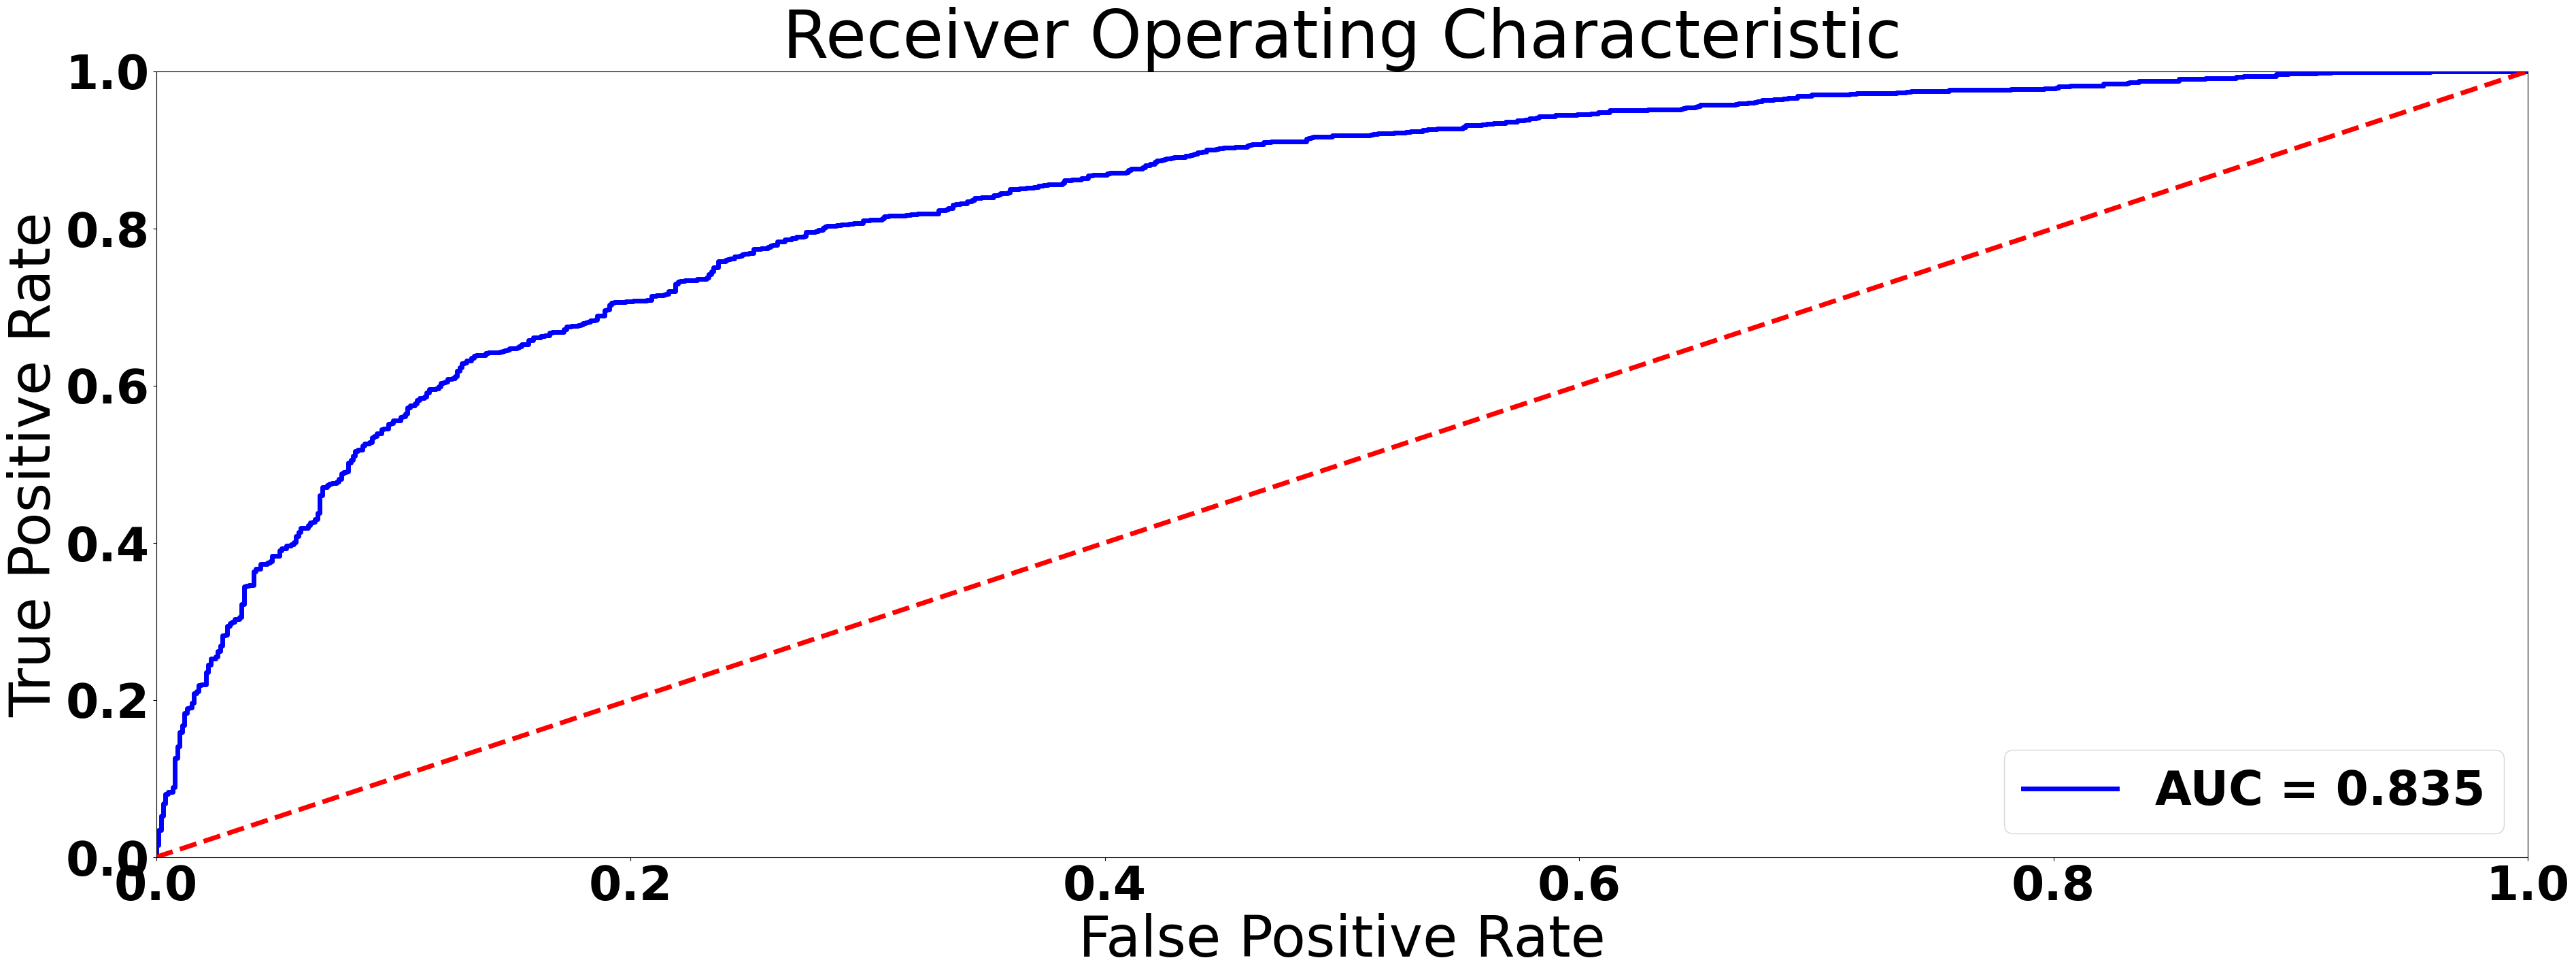

In [55]:
roc_auc = metrics.auc(fpr_AE_R, tpr_AE_R)
    
plt.title('Receiver Operating Characteristic')
plt.plot(fpr_AE_R, tpr_AE_R, 'b', label = 'AUC = %0.3f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
#plt.savefig(save_path + "ROC_" + program + "_TrainSize_" + str(train_amount) + ".png", bbox_inches='tight')
plt.show()

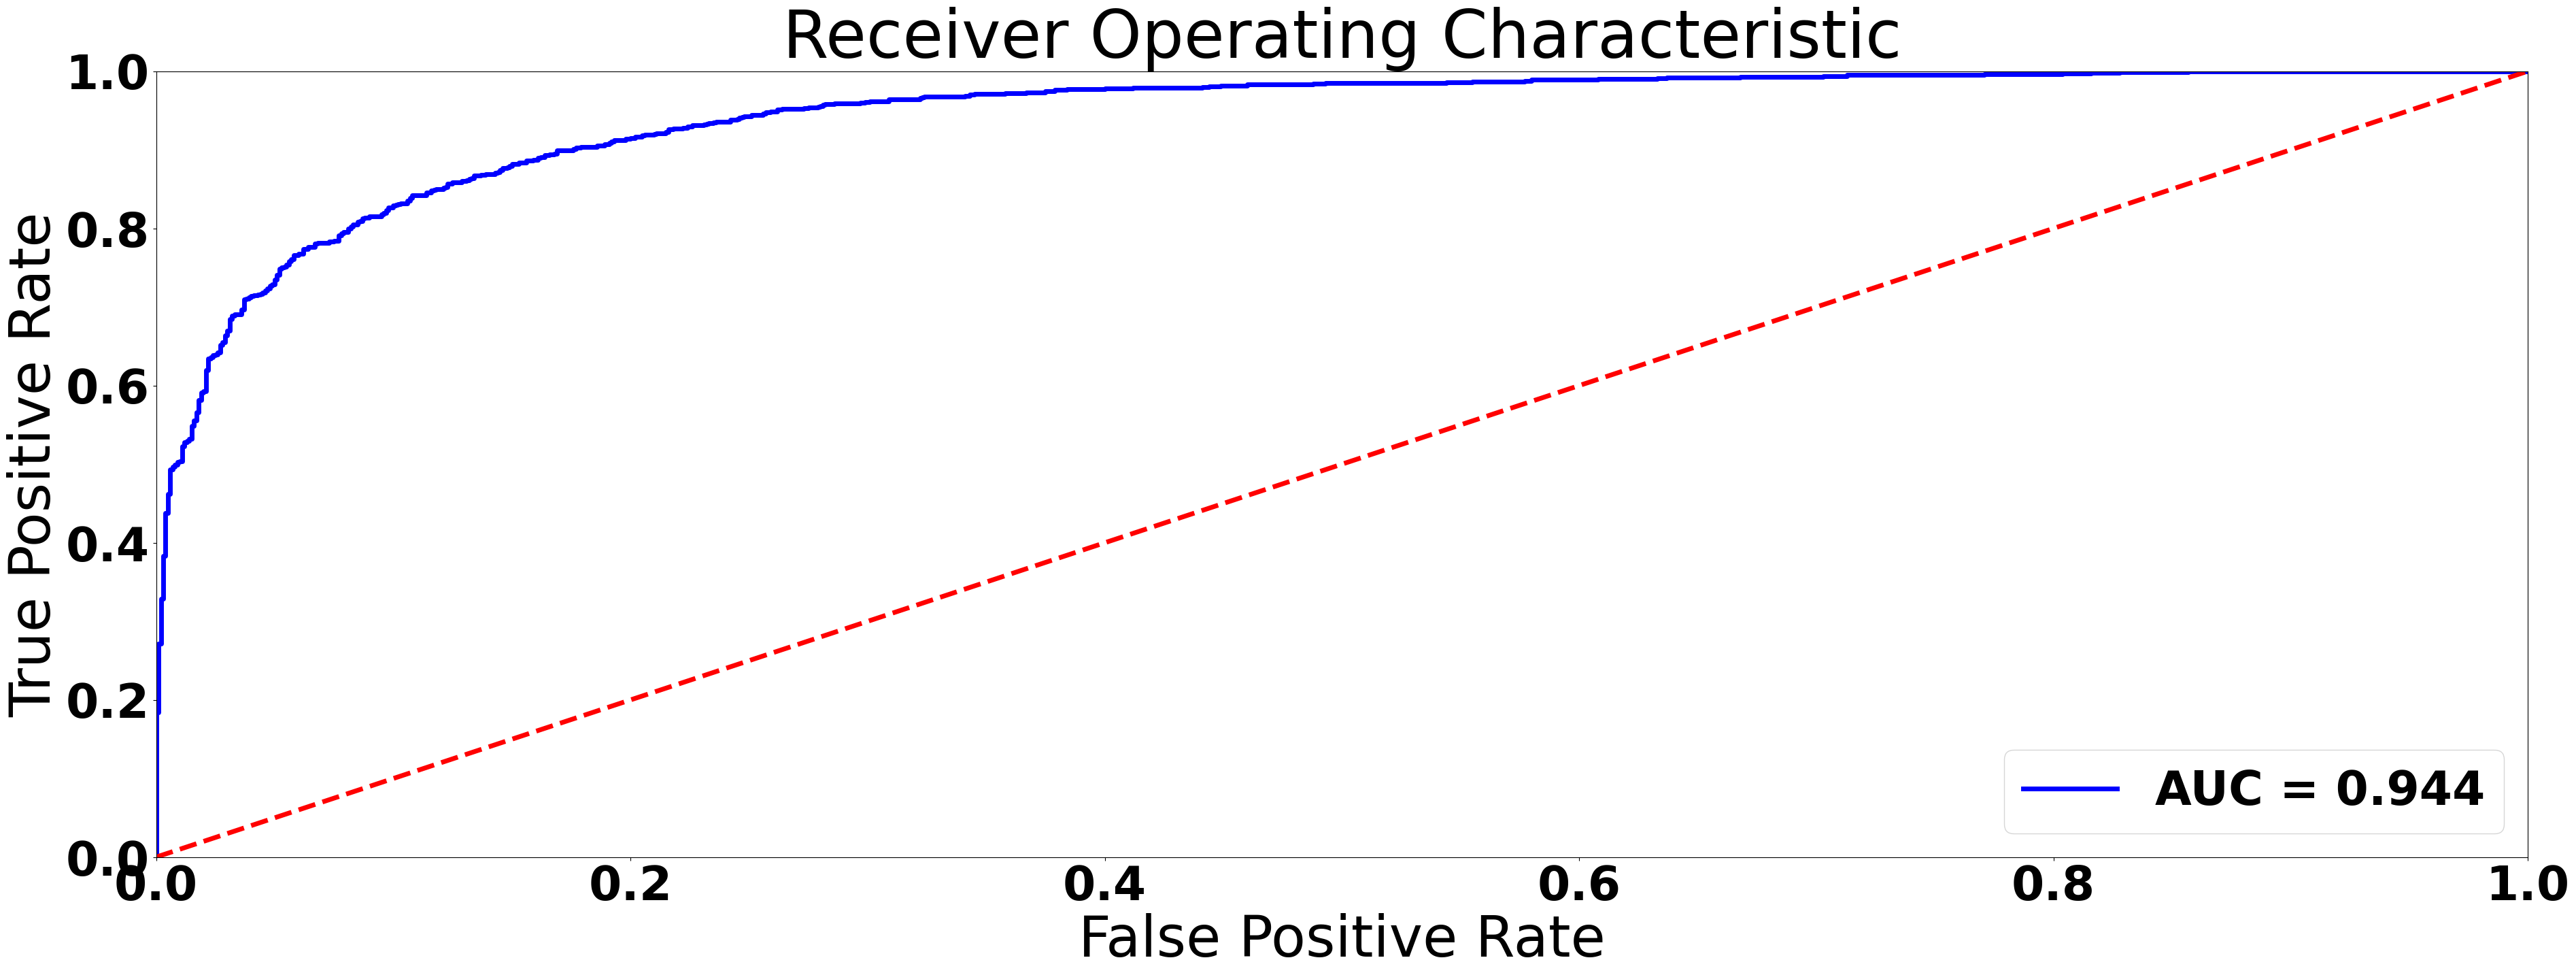

In [45]:
roc_auc = metrics.auc(fpr_AE_S, tpr_AE_S)
    
plt.title('Receiver Operating Characteristic')
plt.plot(fpr_AE_S, tpr_AE_S, 'b', label = 'AUC = %0.3f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
#plt.savefig(save_path + "ROC_" + program + "_TrainSize_" + str(train_amount) + ".png", bbox_inches='tight')
plt.show()

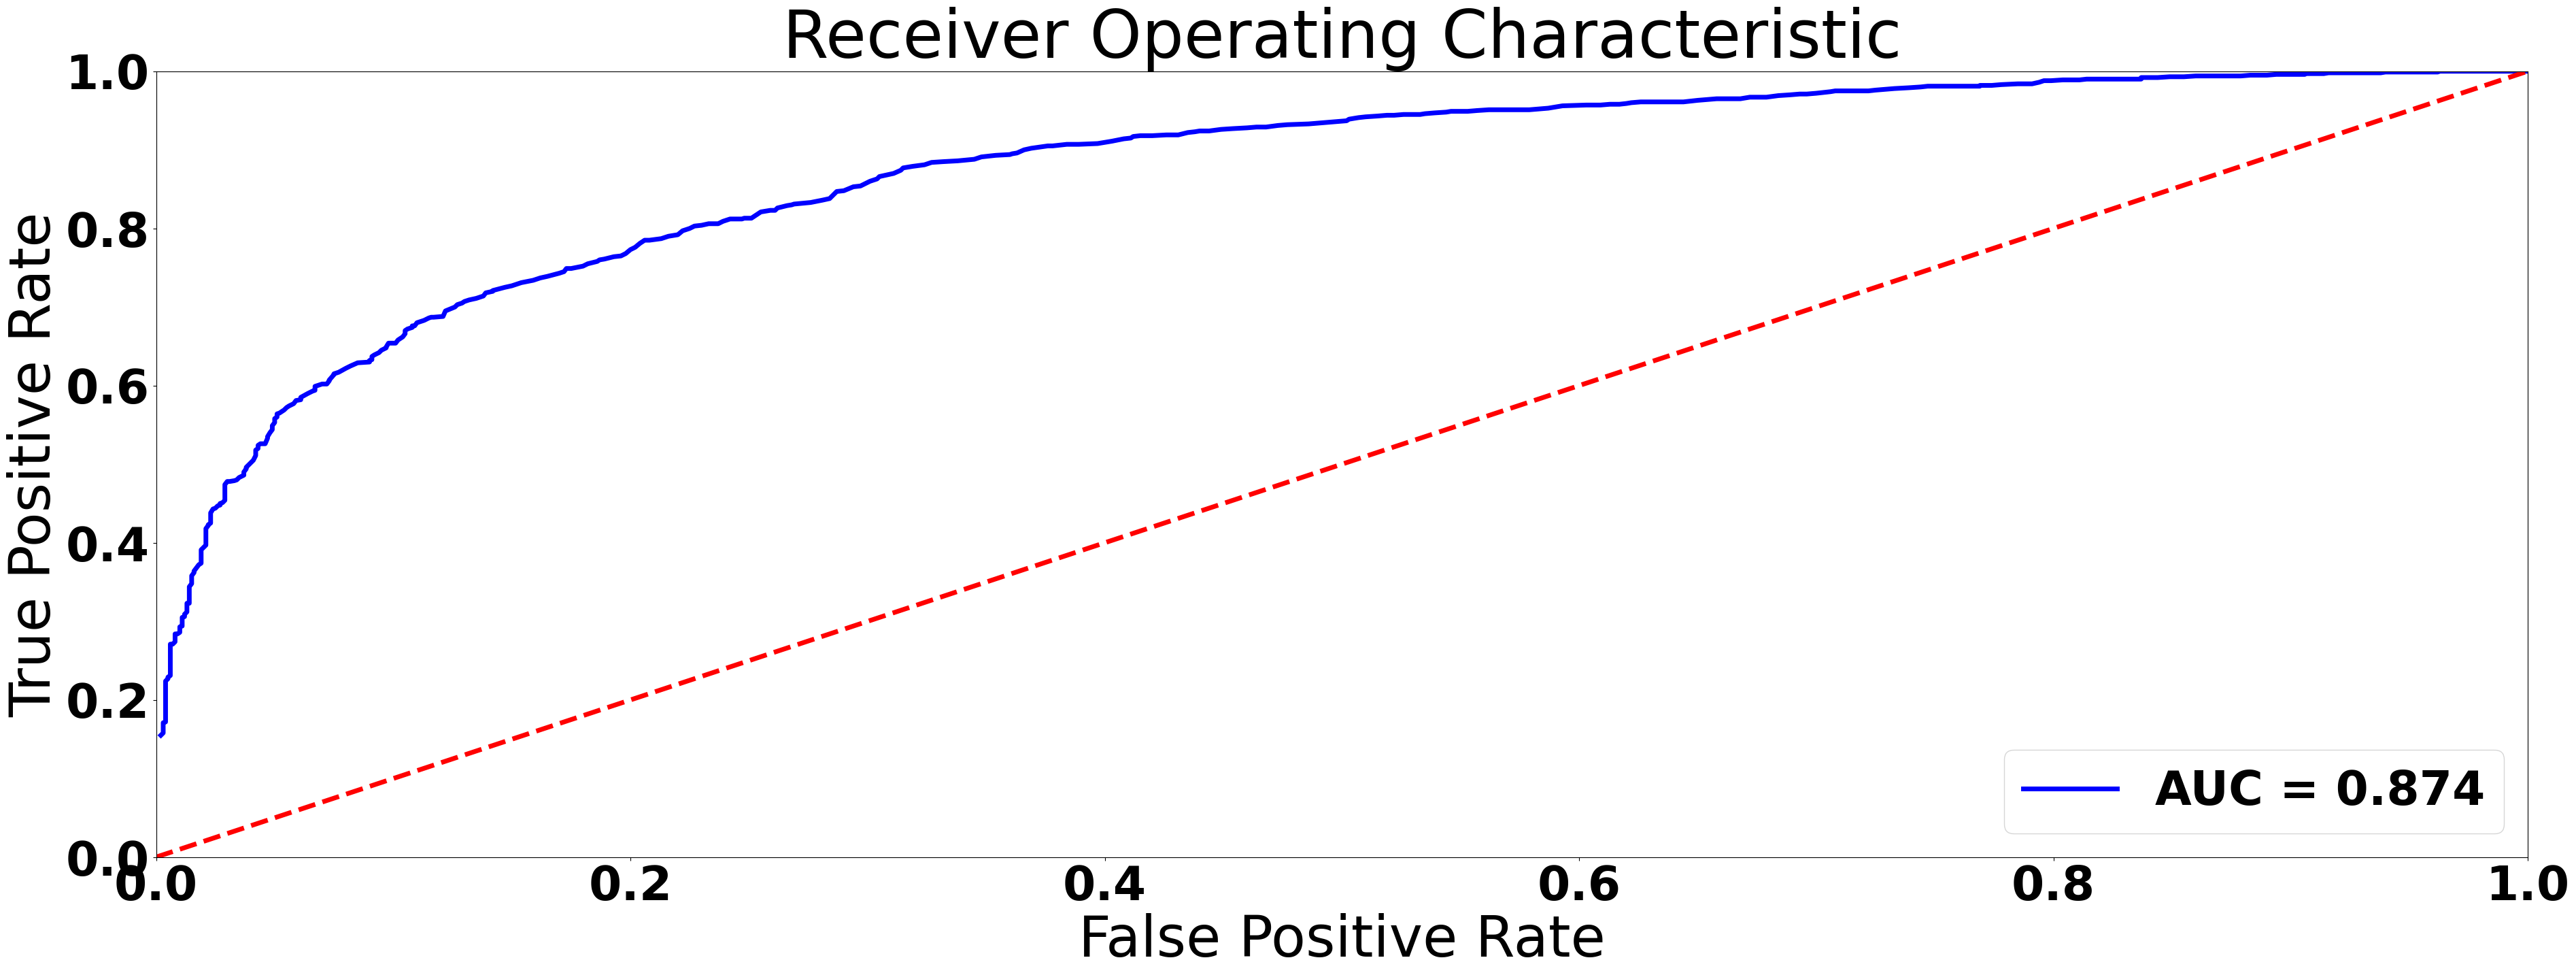

In [50]:
roc_auc = metrics.auc(fpr_KNN_R, tpr_KNN_R)
    
plt.title('Receiver Operating Characteristic')
plt.plot(fpr_KNN_R, tpr_KNN_R, 'b', label = 'AUC = %0.3f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
#plt.savefig(save_path + "ROC_" + program + "_TrainSize_" + str(train_amount) + ".png", bbox_inches='tight')
plt.show()